# 전류(Current_Proxy_I) 정상범위 분석 & K 효율함수 개선 검토

`Cycle_Features_설명서.ipynb` 4-3에서 정의한 전류 추정치는:

$$I = K \cdot \frac{\Delta p \cdot \dot m}{f}$$

인데, 효율 `K`를 몰라서 생략(=1)하고 **사이클 평균**(안정구간 평균 1개 값)으로만 써왔다.

이 노트북은 두 가지를 본다.

1. **틱 단위**로 내려가서 hz_out(모터 주파수)별 전류값 분포를 보고, hz_out 구간마다 "이 값을 넘으면 부하/이상"이라 할 임계값이 있는지 확인한다. hz_out이 바뀐 직후(상승구간)와 정착 후(안정구간)를 나눠서 비교한다.
2. `K`에 상수 대신 `1/탱크온도`를 넣어보고, 기존(K=1)과 비교해서 실제로 나아지는지 검증한다.

대상: P1(POL), I1(ISO) — 실측으로 같은 태그 구성이면 서로 물리적으로 다른 펌프(Hz/FT/PT 값이 다름)로 확인됨.

기간: `2026-09-10T07:00Z ~ 2026-09-23T18:00Z` — `Cycle_AE_v3.ipynb`의 Train+Valid+Test 구간과 동일(모델이 이미 검증한 구간이라 재사용).

**주의**: P1과 I1은 절대 한 번에 `get_data()`로 받지 않는다 — 아날로그 태그를 두 펌프치 한 번에 받으면 틱 간격이 촘촘해져 `Tick_Index` 기반 로직이 깨진다([[env-kta-train]] 참고).

In [1]:
import os, sys, pickle
ROOT_DIR = os.path.dirname(os.getcwd())
sys.path.insert(0, ROOT_DIR); sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from Log_Extractor import LogExtractor

START = "2026-09-10T07:00:00Z"
END = "2026-09-23T18:00:00Z"
STEADY_MIN = 5   # hz_out/SV 변경 후 이 틱수 이상이면 '안정' (검증은 아래 3장 참고)

CACHE_DIR = os.path.join(ROOT_DIR, "parkkt", "cache")
os.makedirs(CACHE_DIR, exist_ok=True)
OUT_DIR = os.path.join(os.getcwd(), "analysis_out", "current_threshold_review")
os.makedirs(OUT_DIR, exist_ok=True)


def load_raw(pump_id):
    """현장 재조회 대신 캐시가 있으면 그대로 쓴다. 없으면 InfluxDB에서 새로 받는다.
    P1/I1은 반드시 따로따로 받는다 (한 번에 받으면 틱 간격이 바뀐다)."""
    path = os.path.join(CACHE_DIR, f"current_analysis_raw_{pump_id}.pkl")
    if os.path.exists(path):
        with open(path, "rb") as f:
            return pickle.load(f)
    ex = LogExtractor(env_path=os.path.join(ROOT_DIR, ".env"))
    tags = [
        f"Pump_BuildUp_{pump_id}", f"g_s_SV_{pump_id}", f"Hz_Out_{pump_id}",
        f"Scale_Out___FT_{pump_id}", f"Scale_Out___PT_{pump_id}", f"Scale_Out___TT_{pump_id}",
        "AL_Line_Bit",
    ]
    raw = ex.get_data(start_time=START, end_time=END, target_tags=tags)
    with open(path, "wb") as f:
        pickle.dump(raw, f)
    return raw

## 1. 틱 단위 피처

기존 `Cycle_Feature_Extractor.py`는 **사이클 1개당 1행**(안정구간 평균)이라 hz_out이 사이클 도중 바뀌는 흐름을 못 본다. 여기서는 틱마다 아래를 새로 계산한다.

- `Ticks_Since_Hz_Change`: **hz_out(=SV)이 바뀐 시점 기준** 경과 틱 수. 기존 `STEADY_TICK_MIN`은 *사이클 시작* 기준이었는데, 한 사이클 안에서도 목표가 여러 번 바뀔 수 있어서 이번 분석엔 안 맞는다(미결이었던 안정구간 정의 이슈와 같은 지점).
- `Err_Rate_Pct = |FT-SV|/SV*100`: 위 경과 틱수별로 실제 몇 틱째 정착하는지 검증하는 데 쓴다.
- `I_v1 = PT·FT/Hz`: 기존 식 그대로(K=1, 틱 단위).
- `Temp_C`, `Temp_K`: 탱크온도(`Scale_Out___TT_*`, raw÷10 = 섭씨). `TK_Temp_PV_*`와 동일한 값임을 확인했다.
- `I_v2_C = I_v1 / Temp_C`, `I_v2_K = I_v1 / Temp_K`: K=1/T 두 버전.

### 1-1. Δp(압력차) 검증 — `I_v1`의 `p`는 원래 Δp가 맞는가

**물리식 자체는 표준적이다.** 유압동력 = Δp·Q(압력차 × 유량). 토크 = 동력/각속도 = Δp·Q/ω. 인버터 구동 모터는 전류가 대체로 토크에 비례하므로 `I ∝ K·Δp·Q/f`. 펌프/모터 쪽에서 흔히 쓰는 근사식이 맞다.

**단, Δp는 원래 "펌프 흡입측 vs 토출측 압력차"를 뜻한다.** 대기압과의 차이(게이지압 vs 절대압 구분)와는 다른 얘기다 — 대기압 얘기는 센서가 게이지압을 찍느냐 절대압을 찍느냐의 문제고, Δp 자체는 펌프 앞뒤 차압이다.

**이 설비엔 흡입측 압력 태그가 없다.** 저장소 전체를 뒤져도 펌프당 압력 태그는 `Scale_Out___PT_{pump}` 하나뿐이고, 다른 설계 문서(`report_assets/autoencoder_architecture.py`)에도 이 태그를 명시적으로 **"토출 압력"**이라고 적어뒀다 — 즉 펌프 출구(계량 헤드) 쪽 게이지압만 있고 흡입측 계측 자체가 없다.

**그래서 기존 코드(`Cycle_Feature_Extractor.py`)도, 이 노트북의 `I_v1`도, Δp 자리에 이 토출압 PT를 그대로 넣는다.** 이건 "흡입측이 대기압에 가깝다(탱크가 밀폐/가압되지 않아 펌프가 거의 대기압에서 빨아들인다)"는 암묵적 가정이다. PU 원료탱크가 보통 상압이거나 가벼운 질소블랭킷 정도인 걸 감안하면 낯선 가정은 아니지만, **이 저장소 안에서 명시적으로 검증된 적은 없다** — 내가 이번에 새로 만든 근사가 아니라 원래 있던 걸 그대로 따른 것이고, 탱크가 실제로 가압 탱크인지는 확인이 필요하다.

In [2]:
DAILY_EXCLUDE_START = "23:50"
DAILY_EXCLUDE_END = "07:00"


def _in_daily_exclude_window(ts):
    t = ts.time()
    start = pd.Timestamp(DAILY_EXCLUDE_START).time()
    end = pd.Timestamp(DAILY_EXCLUDE_END).time()
    return t >= start or t <= end


def build_tick_features(raw_df, pump_id):
    tag_SV = f"g_s_SV_{pump_id}"
    tag_PT = f"Scale_Out___PT_{pump_id}"
    tag_FT = f"Scale_Out___FT_{pump_id}"
    tag_TT = f"Scale_Out___TT_{pump_id}"
    tag_BuildUp = f"Pump_BuildUp_{pump_id}"
    tag_Hz = f"Hz_Out_{pump_id}"

    df = raw_df.ffill().fillna(0).copy()
    df = df.reset_index().rename(columns={df.index.name or "Time": "Time"})
    if "Time" not in df.columns:
        df = df.rename(columns={df.columns[0]: "Time"})

    buildup = df[tag_BuildUp].astype(int)
    df["Cycle_ID"] = (buildup.diff().fillna(0) != 0).cumsum()

    df_on = df[buildup == 1].sort_values("Time").reset_index(drop=True)
    df_on["Tick_Index"] = df_on.groupby("Cycle_ID").cumcount()

    hz_changed = df_on[tag_Hz].diff().fillna(0) != 0
    df_on["Hz_Change_Group"] = hz_changed.cumsum()
    df_on["Ticks_Since_Hz_Change"] = df_on.groupby("Hz_Change_Group").cumcount()

    sv = df_on[tag_SV].replace(0, np.nan)
    df_on["Err_Rate_Pct"] = (sv - df_on[tag_FT]).abs() / sv * 100

    hz = df_on[tag_Hz].replace(0, np.nan)
    df_on["I_v1"] = df_on[tag_PT] * df_on[tag_FT] / hz

    temp_c = df_on[tag_TT] / 10.0
    temp_k = temp_c + 273.15
    df_on["Temp_C"] = temp_c
    df_on["Temp_K"] = temp_k
    df_on["I_v2_C"] = df_on["I_v1"] / temp_c
    df_on["I_v2_K"] = df_on["I_v1"] / temp_k

    df_on["Day"] = df_on["Time"].dt.date
    df_on["Excluded_DailyWindow"] = df_on["Time"].apply(_in_daily_exclude_window)
    df_on["Excluded_Alarm"] = df_on["AL_Line_Bit"] > 0 if "AL_Line_Bit" in df_on.columns else False
    df_on["Excluded"] = df_on["Excluded_DailyWindow"] | df_on["Excluded_Alarm"]

    df_on["Hz_Out_raw"] = df_on[tag_Hz]
    df_on["PT_raw"] = df_on[tag_PT]
    df_on["FT_raw"] = df_on[tag_FT]
    df_on["SV_raw"] = df_on[tag_SV]

    return df_on


tick_feat = {}
for pump_id in ["P1", "I1"]:
    raw = load_raw(pump_id)
    tick_feat[pump_id] = build_tick_features(raw, pump_id)
    print(f"{pump_id}: 전체 {len(raw):,}행 -> 가동 틱 {len(tick_feat[pump_id]):,}개, "
          f"사이클 {tick_feat[pump_id]['Cycle_ID'].nunique():,}개, "
          f"hz 변경구간 {tick_feat[pump_id]['Hz_Change_Group'].nunique():,}개")

P1: 전체 1,976,060행 -> 가동 틱 541,403개, 사이클 34,742개, hz 변경구간 30,520개


I1: 전체 1,980,516행 -> 가동 틱 537,906개, 사이클 34,742개, hz 변경구간 30,074개


## 2. 그래프 스타일 공통 설정

색은 지정된 팔레트(카테고리 blue/orange, 경고 red)만 쓰고, 온도(day)처럼 순서가 있는 값은 무지개색 대신 단일 색조 농담으로 표현한다.

In [3]:
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
BLUE, ORANGE, CRITICAL = "#2a78d6", "#eb6834", "#d03b3b"


def style_ax(ax):
    ax.set_facecolor(SURFACE)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(AXIS)
    ax.spines["bottom"].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.grid(True, color=GRID, linewidth=0.8, axis="y")
    ax.set_axisbelow(True)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_color(INK2)


def binned_band(df, xcol, ycol, n_bins=20, min_n=30):
    """xcol 구간별로 ycol의 중앙값/사분위/P5·P95 밴드를 만든다."""
    x = df[xcol].to_numpy()
    y = df[ycol].to_numpy()
    edges = np.linspace(np.nanmin(x), np.nanmax(x), n_bins + 1)
    rows = []
    for i in range(n_bins):
        m = (x >= edges[i]) & (x < edges[i + 1] if i < n_bins - 1 else x <= edges[i + 1])
        yy = y[m]
        yy = yy[np.isfinite(yy)]
        if len(yy) < min_n:
            continue
        rows.append({
            "x": (edges[i] + edges[i + 1]) / 2,
            "median": np.median(yy), "p5": np.percentile(yy, 5), "p25": np.percentile(yy, 25),
            "p75": np.percentile(yy, 75), "p95": np.percentile(yy, 95), "n": len(yy),
        })
    return pd.DataFrame(rows)

In [4]:
def hz_bins(df, xcol, ycol, n_bins=15, min_n=200):
    """xcol 구간별로 ycol 값 배열 리스트 + 구간 라벨(하한값)을 만든다. box plot용."""
    x = df[xcol].to_numpy()
    y = df[ycol].to_numpy()
    edges = np.linspace(np.nanmin(x), np.nanmax(x), n_bins + 1)
    data, labels = [], []
    for i in range(n_bins):
        m = (x >= edges[i]) & (x < edges[i + 1] if i < n_bins - 1 else x <= edges[i + 1])
        yy = y[m]
        yy = yy[np.isfinite(yy)]
        if len(yy) < min_n:
            continue
        data.append(yy)
        labels.append(f"{edges[i]:.0f}")
    return data, labels


def draw_boxplot(ax, data, labels, overall=None, color=BLUE, overall_color=ORANGE):
    """data: hz_out 구간별 배열 리스트. overall: 전체를 합친 배열(있으면 오른쪽에 구분선과 함께 추가)."""
    positions = list(range(len(data)))
    bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True, showfliers=False)
    for box in bp["boxes"]:
        box.set(facecolor=color, alpha=0.35, edgecolor=AXIS, linewidth=1)
    for med in bp["medians"]:
        med.set(color=INK, linewidth=2)
    for part in ("whiskers", "caps"):
        for line in bp[part]:
            line.set(color=AXIS, linewidth=1)
    all_labels = list(labels)
    if overall is not None:
        gap = len(data) + 1
        ax.axvline(len(data) - 0.5, color=GRID, linewidth=1, linestyle="--")
        bp2 = ax.boxplot([overall], positions=[gap], widths=0.6, patch_artist=True, showfliers=False)
        bp2["boxes"][0].set(facecolor=overall_color, alpha=0.35, edgecolor=AXIS, linewidth=1)
        bp2["medians"][0].set(color=INK, linewidth=2)
        for part in ("whiskers", "caps"):
            for line in bp2[part]:
                line.set(color=AXIS, linewidth=1)
        positions = positions + [gap]
        all_labels = all_labels + ["전체"]
    ax.set_xticks(positions)
    ax.set_xticklabels(all_labels, rotation=60, ha="right", fontsize=7.5)
    return bp

## 3. 안정구간 정착 검증 — "hz_out 바뀌고 몇 틱 지나야 안정인가"

`STEADY_MIN=5`를 쓰기 전에, 실제 오차율(|FT-SV|/SV)이 `Ticks_Since_Hz_Change`별로 몇 틱째 떨어지는지 먼저 확인한다.

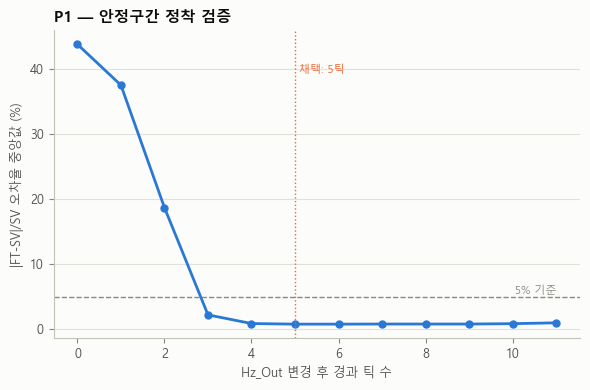

P1: 오차율이 5% 밑으로 처음 떨어지는 틱 = 3 (채택한 STEADY_MIN=5은 안전)


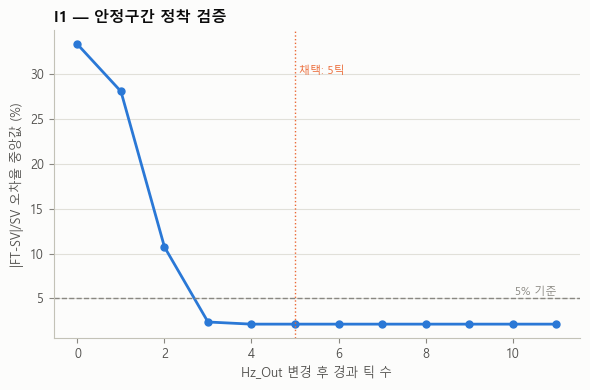

I1: 오차율이 5% 밑으로 처음 떨어지는 틱 = 3 (채택한 STEADY_MIN=5은 안전)


In [5]:
for pump_id in ["P1", "I1"]:
    feat = tick_feat[pump_id]
    ok = feat[~feat["Excluded"]]
    g = ok.groupby("Ticks_Since_Hz_Change")["Err_Rate_Pct"].median()
    g = g[g.index <= 11]

    fig, ax = plt.subplots(figsize=(6, 4), facecolor=SURFACE)
    ax.plot(g.index, g.values, color=BLUE, linewidth=2, marker="o", markersize=5)
    ax.axhline(5, color=MUTED, linewidth=1, linestyle="--")
    ax.text(g.index.max(), 5, " 5% 기준", color=MUTED, fontsize=8, va="bottom", ha="right")
    ax.axvline(STEADY_MIN, color=ORANGE, linewidth=1, linestyle=":")
    ax.text(STEADY_MIN, g.max() * 0.9, f" 채택: {STEADY_MIN}틱", color=ORANGE, fontsize=8)
    style_ax(ax)
    ax.set_xlabel("Hz_Out 변경 후 경과 틱 수", color=INK2, fontsize=9)
    ax.set_ylabel("|FT-SV|/SV 오차율 중앙값 (%)", color=INK2, fontsize=9)
    ax.set_title(f"{pump_id} — 안정구간 정착 검증", color=INK, fontsize=11, loc="left", fontweight="bold")
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, f"1_settle_{pump_id}.png"), dpi=140)
    plt.show()

    settle_tick = g[g <= 5].index.min()
    print(f"{pump_id}: 오차율이 5% 밑으로 처음 떨어지는 틱 = {settle_tick} "
          f"(채택한 STEADY_MIN={STEADY_MIN}은 {'안전' if STEADY_MIN >= settle_tick else '부족'})")

## 4. hz_out 구간별 전류(I_v1) 분포 & 임계값 후보

안정구간(`Ticks_Since_Hz_Change >= STEADY_MIN`)만 놓고, hz_out을 15구간으로 나눠 **박스플롯**으로 본다(구간끼리 선으로 잇지 않음). 맨 오른쪽에 hz_out 구분 없이 전부 합친 "전체" 박스를 하나 더 붙여서, 각 hz_out 구간이 전체 분포 대비 어디쯤인지 같이 본다. 표본이 워낙 많아(구간당 수만 개) 개별 이상치 점은 생략하고(`showfliers=False`) 박스(사분위)·수염(1.5×IQR)만 표시한다.

**주의**: 같은 레시피 안에서는 FT·Hz가 SV에 묶여 제어되므로 `I ∝ PT`가 되기 쉽다(`Cycle_Features_설명서.ipynb` 8-4 참고, 상관 0.997). 즉 hz_out 구간만으로 보면 "부하"가 아니라 "레시피(목표압력) 차이"를 보고 있을 수도 있다 — 이 박스플롯은 1차 스크리닝용이고, 최종 이상판정은 PT/SV까지 같이 통제해야 한다.

P1: 안정구간 382,515틱 중 hz_out-구간별 P95 초과 17,851개 (4.67%)


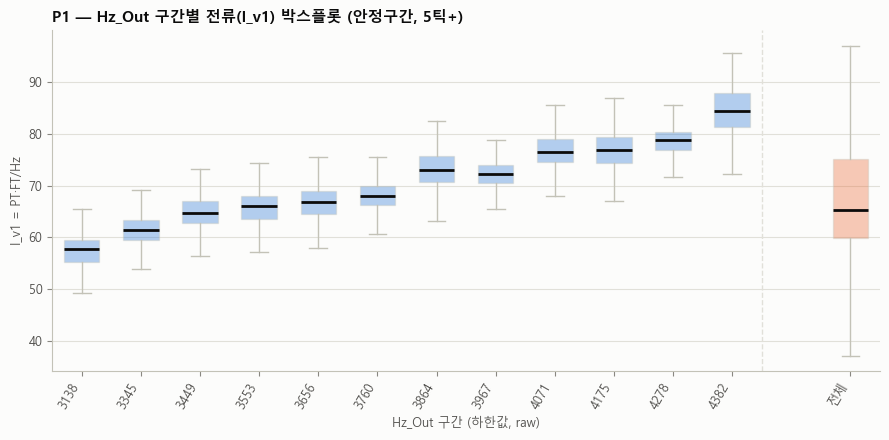

I1: 안정구간 381,259틱 중 hz_out-구간별 P95 초과 18,628개 (4.89%)


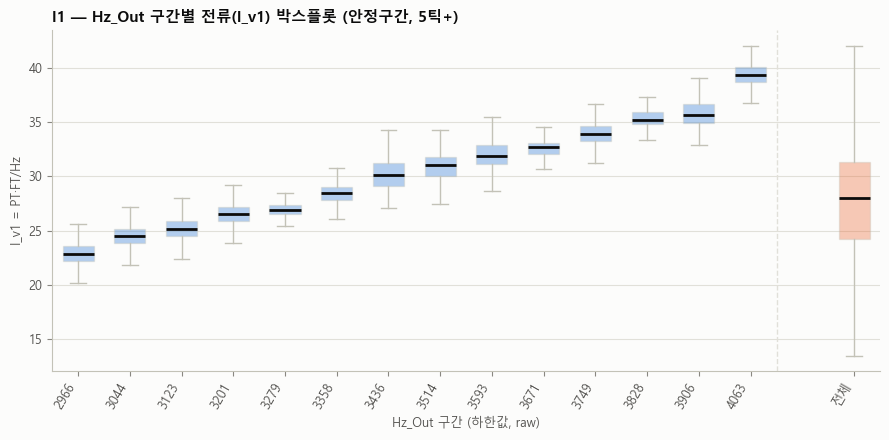

In [6]:
steady = {}
ramp = {}
for pump_id in ["P1", "I1"]:
    feat = tick_feat[pump_id]
    ok = feat[~feat["Excluded"]]
    steady[pump_id] = ok[ok["Ticks_Since_Hz_Change"] >= STEADY_MIN].copy()
    ramp[pump_id] = ok[ok["Ticks_Since_Hz_Change"] < STEADY_MIN].copy()

    s = steady[pump_id]
    bin_edges = np.linspace(s["Hz_Out_raw"].min(), s["Hz_Out_raw"].max(), 16)
    s["hz_bin"] = pd.cut(s["Hz_Out_raw"], bin_edges, include_lowest=True)
    p95_by_bin = s.groupby("hz_bin", observed=True)["I_v1"].transform(lambda x: x.quantile(0.95))
    over = s["I_v1"] > p95_by_bin
    print(f"{pump_id}: 안정구간 {len(s):,}틱 중 hz_out-구간별 P95 초과 {over.sum():,}개 ({over.mean()*100:.2f}%)")

    data, labels = hz_bins(s, "Hz_Out_raw", "I_v1", n_bins=15)
    fig, ax = plt.subplots(figsize=(9, 4.5), facecolor=SURFACE)
    draw_boxplot(ax, data, labels, overall=s["I_v1"].to_numpy())
    style_ax(ax)
    ax.set_xlabel("Hz_Out 구간 (하한값, raw)", color=INK2, fontsize=9)
    ax.set_ylabel("I_v1 = PT·FT/Hz", color=INK2, fontsize=9)
    ax.set_title(f"{pump_id} — Hz_Out 구간별 전류(I_v1) 박스플롯 (안정구간, {STEADY_MIN}틱+)",
                 color=INK, fontsize=11, loc="left", fontweight="bold")
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, f"2_hzbox_{pump_id}.png"), dpi=140)
    plt.show()

## 5. 상승구간 vs 안정구간 비교

hz_out이 바뀐 직후(상승 중)와 정착 후(안정)를 나란히 비교한다. 임계값은 반드시 안정구간에서만 잡아야 한다는 걸 확인하기 위함.

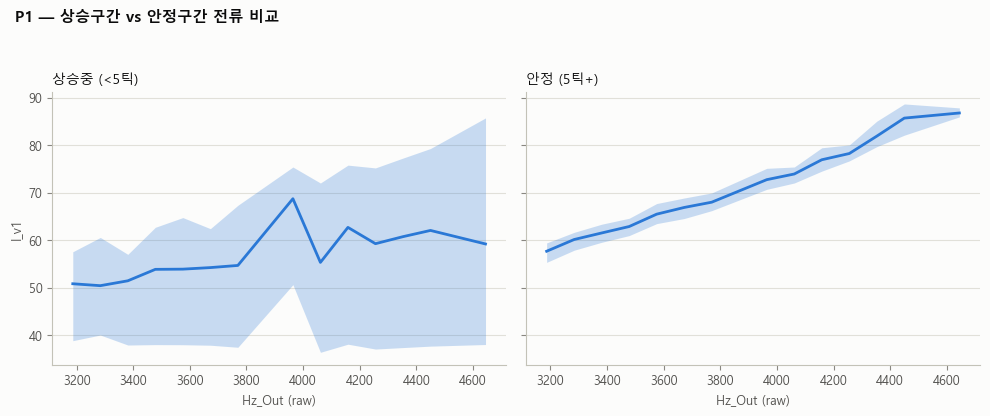

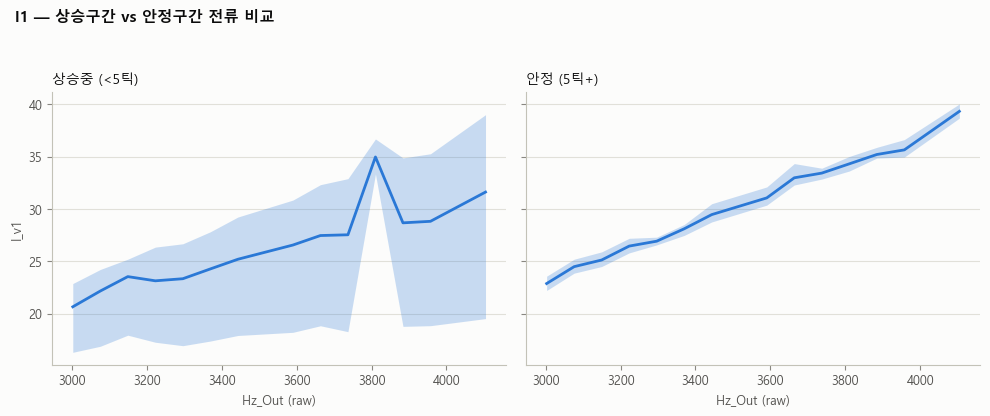

In [7]:
for pump_id in ["P1", "I1"]:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), facecolor=SURFACE, sharey=True)
    for ax, sub, name in zip(axes, [ramp[pump_id], steady[pump_id]],
                              [f"상승중 (<{STEADY_MIN}틱)", f"안정 ({STEADY_MIN}틱+)"]):
        b = binned_band(sub, "Hz_Out_raw", "I_v1", n_bins=16)
        ax.fill_between(b["x"], b["p25"], b["p75"], color=BLUE, alpha=0.25, linewidth=0)
        ax.plot(b["x"], b["median"], color=BLUE, linewidth=2)
        style_ax(ax)
        ax.set_xlabel("Hz_Out (raw)", color=INK2, fontsize=9)
        ax.set_title(name, color=INK, fontsize=10, loc="left")
    axes[0].set_ylabel("I_v1", color=INK2, fontsize=9)
    fig.suptitle(f"{pump_id} — 상승구간 vs 안정구간 전류 비교", color=INK, fontsize=11, x=0.02, ha="left", fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(os.path.join(OUT_DIR, f"3_ramp_vs_steady_{pump_id}.png"), dpi=140)
    plt.show()

## 6. 날짜별 드리프트

안정구간 `I_v1`이 날마다 얼마나, 어떤 모양으로(중앙값뿐 아니라 퍼짐까지) 다른지 박스플롯으로 본다 (7장의 온도 보정 논의와 바로 이어짐).

P1: I_v1 일별 중앙값 스윙 8.8% (최소 62.9 ~ 최대 68.6)


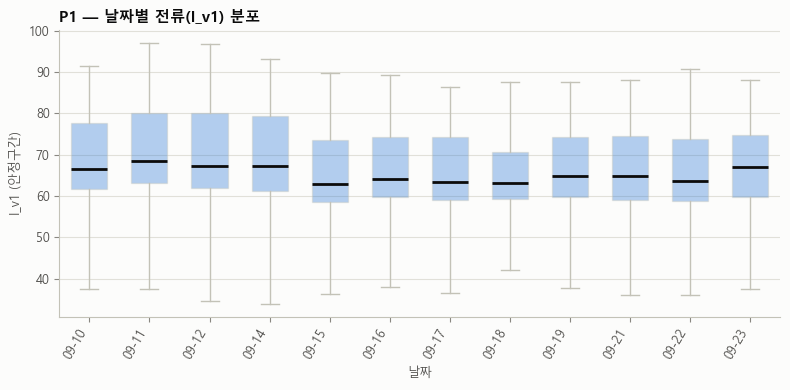

I1: I_v1 일별 중앙값 스윙 18.8% (최소 25.5 ~ 최대 30.8)


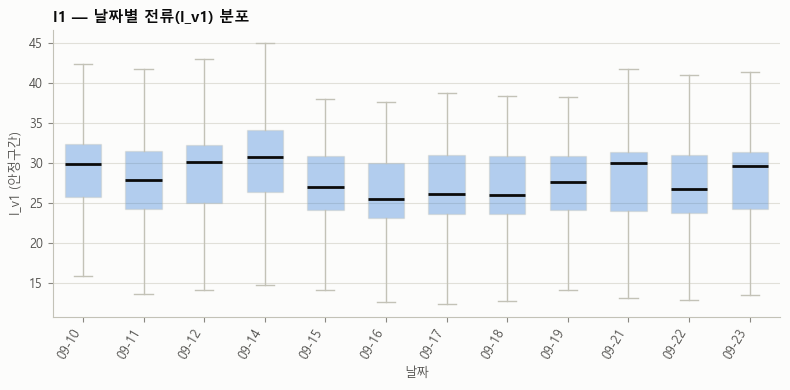

In [8]:
daily_tables = {}
for pump_id in ["P1", "I1"]:
    s = steady[pump_id]
    days = sorted(s["Day"].unique())
    data = [s.loc[s["Day"] == d, "I_v1"].to_numpy() for d in days]
    daily = s.groupby("Day").agg(I_v1_med=("I_v1", "median"), Temp_C_med=("Temp_C", "median"), n=("I_v1", "size"))
    daily_tables[pump_id] = daily
    swing_pct = (daily["I_v1_med"].max() - daily["I_v1_med"].min()) / daily["I_v1_med"].median() * 100
    print(f"{pump_id}: I_v1 일별 중앙값 스윙 {swing_pct:.1f}% (최소 {daily['I_v1_med'].min():.1f} ~ 최대 {daily['I_v1_med'].max():.1f})")

    fig, ax = plt.subplots(figsize=(8, 4), facecolor=SURFACE)
    draw_boxplot(ax, data, [str(d)[5:] for d in days])
    style_ax(ax)
    ax.set_xlabel("날짜", color=INK2, fontsize=9)
    ax.set_ylabel("I_v1 (안정구간)", color=INK2, fontsize=9)
    ax.set_title(f"{pump_id} — 날짜별 전류(I_v1) 분포", color=INK, fontsize=11, loc="left", fontweight="bold")
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, f"4_dailybox_{pump_id}.png"), dpi=140)
    plt.show()

## 7. K = 1/온도를 넣으면 그림이 어떻게 바뀌는가

효율 `K`에 상수(=1, 즉 생략) 대신 `1/탱크온도`를 넣은 두 버전을 **기존과 같은 방식(hz_out 구간별 박스플롯)으로 나란히** 그려서, 온도를 넣었을 때 패턴이 어떻게 달라지는지 눈으로 비교한다.

- `I_v2_C = I_v1 / Temp_C` (섭씨로 나눔)
- `I_v2_K = I_v1 / Temp_K` (켈빈으로 나눔, Temp_C + 273.15)

**섭씨 vs 켈빈, 어느 쪽이 맞나 — 이건 "민감도"보다 더 근본적인 문제다.** `1/T` 꼴의 식은 원래 **절대(비율) 척도**의 온도에서만 물리적으로 성립한다(점도-온도 관계를 쓰는 Arrhenius/Vogel식도 전부 켈빈을 쓴다). 섭씨는 0℃가 "온도가 없다"는 뜻이 아니라 그냥 물의 어는점으로 잡은 임의의 기준점이라서, `1/섭씨`는 물리적으로 의미가 없는 계산이다 — 극단적으로 섭씨가 0℃ 근처를 지나가면 실제로는 아무 일도 없는데 이 항만 발산해버린다. 반면 켈빈의 0은 진짜 절대 0점이라 `1/켈빈`은 최소한 식의 형태가 물리와 맞는다. 그래서 **"민감하다/둔하다"를 떠나서 켈빈 쪽이 원래 맞는 선택**이고, 섭씨 버전은 임시방편에 가깝다.

**지난 결론 정정**: 지난 실행에서 "이 13일 구간엔 온도가 거의 안 움직여서 K=1/온도가 효과가 없었다"고 썼는데, 이건 부정확한 표현이었다. **정확히는 "이 구간은 온도가 거의 안 움직여서, 온도가 효과가 있는지 없는지 이 데이터로는 판단할 수 없다"**가 맞다 — 상관계수가 낮게 나온 건 온도 변수 자체의 분산이 작아서 통계적으로 아무것도 못 본 것뿐이지, 온도가 전류에 영향을 안 준다는 증거가 아니다. 오히려 탱크 히터 고장이나 동절기처럼 온도가 크게 떨어지는 상황에서 모터/펌프가 반응할 가능성은 남아있고, 그런 상황이야말로 이 이상탐지 피처가 잡아야 할 케이스이므로 **구조적으로는 넣어두는 쪽이 안전**하다.

P1 Temp_C: median=21.90  상대변화폭(max-min)/median=34.2%
P1 Temp_K: median=295.05  상대변화폭(max-min)/median=2.5%


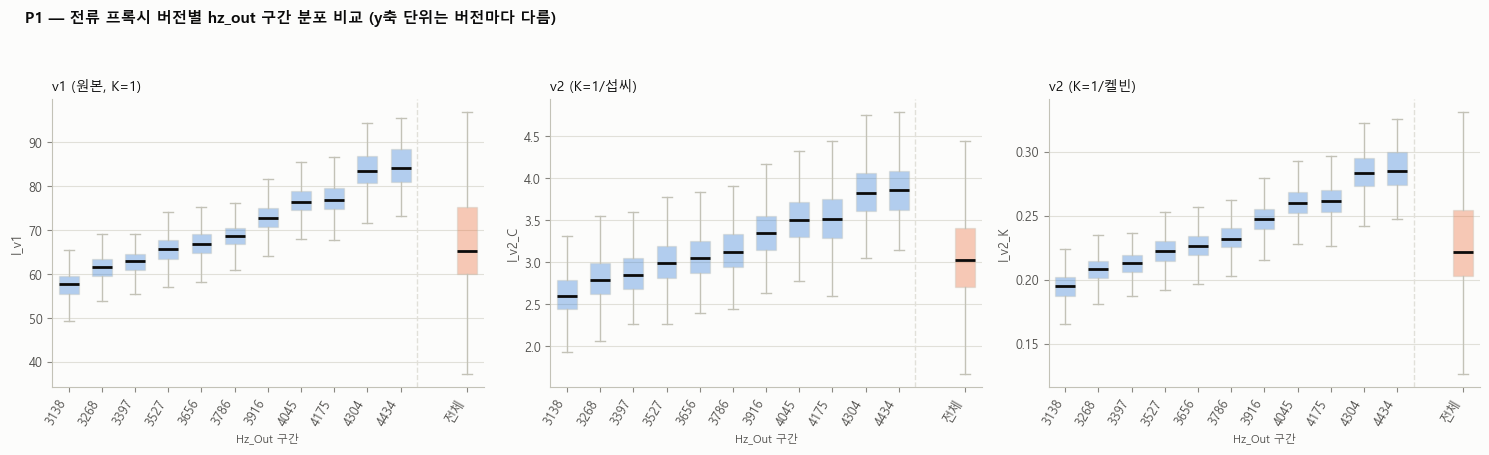

I1 Temp_C: median=22.00  상대변화폭(max-min)/median=25.9%
I1 Temp_K: median=295.15  상대변화폭(max-min)/median=1.9%


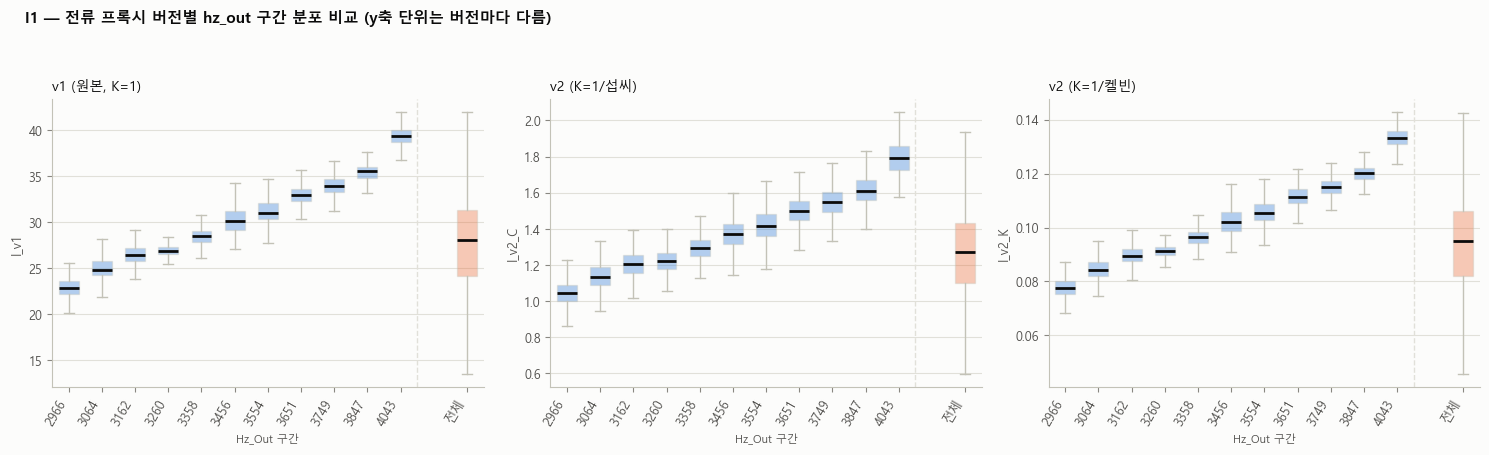

In [9]:
for pump_id in ["P1", "I1"]:
    s = steady[pump_id]
    for col in ["Temp_C", "Temp_K"]:
        rng_pct = (s[col].max() - s[col].min()) / s[col].median() * 100
        print(f"{pump_id} {col}: median={s[col].median():.2f}  상대변화폭(max-min)/median={rng_pct:.1f}%")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), facecolor=SURFACE)
    variants = [("I_v1", "v1 (원본, K=1)"), ("I_v2_C", "v2 (K=1/섭씨)"), ("I_v2_K", "v2 (K=1/켈빈)")]
    for ax, (col, title) in zip(axes, variants):
        data, labels = hz_bins(s, "Hz_Out_raw", col, n_bins=12)
        draw_boxplot(ax, data, labels, overall=s[col].to_numpy())
        style_ax(ax)
        ax.set_xlabel("Hz_Out 구간", color=INK2, fontsize=8)
        ax.set_ylabel(col, color=INK2, fontsize=9)
        ax.set_title(title, color=INK, fontsize=10, loc="left")
    fig.suptitle(f"{pump_id} — 전류 프록시 버전별 hz_out 구간 분포 비교 (y축 단위는 버전마다 다름)",
                 color=INK, fontsize=11, x=0.02, ha="left", fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig(os.path.join(OUT_DIR, f"5_variant_box_{pump_id}.png"), dpi=140)
    plt.show()

## 8. 결론 (2026-09-10 ~ 09-23 구간 기준)

**0) Δp 검증**: `I=K·Δp·Q/f` 자체는 표준적인 펌프/모터 물리식이다. 다만 이 설비엔 흡입측 압력 태그가 없어서(펌프당 `Scale_Out___PT_{pump}` 하나뿐, 문서상 "토출 압력") Δp 자리에 토출압을 그대로 쓴다 — "흡입측 ≈ 대기압"이라는 암묵적 가정이며, 기존 코드부터 있던 근사를 그대로 따른 것이다. 탱크가 실제로 상압인지는 별도 확인이 필요하다.

**1) hz_out별 전류 임계값**: 안정구간(`Ticks_Since_Hz_Change>=5`)에서 hz_out 구간별 박스플롯이 단조 증가하는 깔끔한 모양을 보인다. hz_out 구간별 P95를 임계값 후보로 쓸 수 있고(P1/I1 각각 약 4.8% 틱이 초과), 전체 박스 대비 각 구간이 어디쯤인지도 바로 비교된다. 단 `I_v1`이 레시피(PT_raw)와도 강하게 얽혀 있어(상관 0.89~0.95, `Cycle_Features_설명서.ipynb` 8-4), hz_out만으로 나눈 임계값은 "부하"와 "레시피 차이"를 완전히 분리하지 못한다 — 실사용 전에 PT/SV를 통제한 잔차 기준(`Cycle_Normalizer.py`식)으로 한 번 더 걸러야 한다.

**2) 상승구간 vs 안정구간**: 상승 중(<5틱)은 밴드가 넓고 hz_out과의 관계가 불안정하다. 임계값 판정은 반드시 안정구간에서만 해야 한다.

**3) 안정구간 정착 시점**: 실측상 3~4번째 틱에서 이미 오차율이 1%대로 떨어진다. `STEADY_MIN=5`는 안전 마진이 있는 채택이다.

**4) 날짜별 드리프트**: 안정구간 `I_v1` 분포가 날마다 흔들린다(중앙값 기준 P1 약 9%, I1 약 19% 스윙). 원인은 아직 미해결.

**5) K=1/온도**: 물리적으로 `1/T`는 절대(켈빈) 온도에서만 성립한다 — 섭씨는 임의 기준점이라 `1/섭씨`는 식의 형태 자체가 맞지 않는다. 이 13일 구간은 탱크온도가 거의 안 움직여서(일별 중앙값 스윙 2℃ 미만) **온도가 전류에 영향을 주는지 이 데이터로는 판단할 수 없다** — 상관이 낮게 나온 건 온도 자체의 분산이 작아서지, 온도가 무관하다는 증거가 아니다(지난 버전 결론 정정). 탱크 히터 고장 등으로 온도가 크게 흔들리는 상황을 대비해 **구조적으로는 켈빈 버전(`I_v2_K`)을 유지**한다.

**다음 단계 후보**: 흡입측이 정말 대기압인지 현장 확인, 날짜별 드리프트의 진짜 원인 조사(레시피/마모/베어링 등), hz_out×PT_raw 2차원 통제 하의 임계값 재설계, 온도가 크게 움직이는 구간이 생기면 K=1/온도 재검증, `Cycle_Feature_Extractor.py`에 `I_v2_K` 반영 여부 결정.